In [1]:
# 0. Install dan import
!pip install -q kagglehub transformers datasets accelerate sentencepiece scikit-learn

import os
import random
import shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

import torch
import kagglehub
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

In [ ]:
# 0b. Install dependency BERTopic (post-training topic modeling)
!pip install -q bertopic sentence-transformers umap-learn hdbscan


**Catatan BERTopic:** BERTopic dijalankan setelah training classifier IndoBERT (post-training), sehingga tidak mempengaruhi akurasi maupun kecepatan training baseline.


In [2]:
# 1. Config
@dataclass
class Config:
    path_cnn: str = "/content/dataset/Summarized_CNN.csv"
    path_detik: str = "/content/dataset/Summarized_Detik.csv"
    path_kompas: str = "/content/dataset/Summarized_Kompas.csv"
    path_tbh: str = "/content/dataset/Summarized_TurnBackHoax.csv"
    path_extra: str = "/content/dataset/Summarized_2020+.csv"
    model_name: str = "indolem/indobert-base-uncased"
    max_length: int = 256
    train_batch_size: int = 96
    eval_batch_size: int = 384
    grad_accumulation: int = 2
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    num_epochs: int = 3
    seed: int = 42
    balance_minority: bool = True

    output_dir: str = "indobert_hoax_model_v3"


cfg = Config()
set_seed(cfg.seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
# 1b. Config BERTopic (post-training, opsional)
ENABLE_BERTOPIC = True
ENABLE_BERTOPIC_UPLOAD = False

BERTOPIC_OUTPUT_DIR = "/content/bertopic_model_v1"
BERTOPIC_EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
BERTOPIC_EMBED_BATCH_SIZE = 32
BERTOPIC_MAX_DOCS = None
BERTOPIC_TOPIC_REPO_ID = "fjrmhri/TA-FINAL-BERTopic"

BERTOPIC_RANDOM_SEED = cfg.seed

print("BERTopic enabled:", ENABLE_BERTOPIC)
print("BERTopic output dir:", BERTOPIC_OUTPUT_DIR)
print("BERTopic embedding model:", BERTOPIC_EMBEDDING_MODEL)


In [3]:
# Donwload  data dari kaggle
import kagglehub

# Download latest version
kaggle_cache_dir = kagglehub.dataset_download("fjrmhri/dataset-berita")
print("Path dataset (cache kagglehub):", kaggle_cache_dir)

from pathlib import Path
import shutil

content_dir = Path("/content/dataset")
content_dir.mkdir(parents=True, exist_ok=True)

file_mapping = {
    "Summarized_CNN.csv": ["dataset/Summarized_CNN.csv"],
    "Summarized_Detik.csv": ["dataset/Summarized_Detik.csv"],
    "Summarized_Kompas.csv": ["dataset/Summarized_Kompas.csv"],
    "Summarized_TurnBackHoax.csv": ["dataset/Summarized_TurnBackHoax.csv"],
    "Summarized_2020+.csv": ["dataset/Summarized_2020+.csv"],
}

for dst_name, candidates in file_mapping.items():
    found = None
    for candidate in candidates:
        candidate_path = Path(kaggle_cache_dir) / candidate
        if candidate_path.exists():
            found = candidate_path
            break
    if found is None:
        raise FileNotFoundError(
            f"Tidak menemukan berkas untuk {dst_name} di {kaggle_cache_dir}"
        )
    shutil.copy(found, content_dir / dst_name)
    print(f"Copied {found.name} -> {content_dir / dst_name}")

print("Dataset siap di /content/dataset")

100%|██████████| 98.2M/98.2M [00:05<00:00, 18.0MB/s]

Extracting files...


Path dataset (cache kagglehub): /root/.cache/kagglehub/datasets/fjrmhri/dataset-berita/versions/1
Copied Summarized_CNN.csv -> /content/dataset/Summarized_CNN.csv
Copied Summarized_Detik.csv -> /content/dataset/Summarized_Detik.csv
Copied Summarized_Kompas.csv -> /content/dataset/Summarized_Kompas.csv
Copied Summarized_TurnBackHoax.csv -> /content/dataset/Summarized_TurnBackHoax.csv
Copied Summarized_2020+.csv -> /content/dataset/Summarized_2020+.csv
Dataset siap di /content/dataset


In [4]:
# 2. data loading dan helpers
BASE_COLS = [
    "url",
    "judul",
    "tanggal",
    "isi_berita",
    "Narasi",
    "Clean Narasi",
    "hoax",
    "summary",
]


def load_single_dataset(path: str, source_name: str) -> pd.DataFrame:
    """Load 1 CSV dan align kolom ke struktur standar."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}")

    print(f"\nMembaca: {path} (source={source_name})")
    df = pd.read_csv(path)
    print("  Kolom:", list(df.columns))

    for col in BASE_COLS:
        if col not in df.columns:
            df[col] = "" if col != "hoax" else np.nan

    df = df[BASE_COLS].copy()
    df["source"] = source_name
    return df


def load_all_datasets(cfg: Config) -> pd.DataFrame:
    frames: List[pd.DataFrame] = []
    frames.append(load_single_dataset(cfg.path_cnn, "cnn"))
    frames.append(load_single_dataset(cfg.path_detik, "detik"))
    frames.append(load_single_dataset(cfg.path_kompas, "kompas"))
    frames.append(load_single_dataset(cfg.path_tbh, "turnbackhoax"))
    frames.append(load_single_dataset(cfg.path_extra, "merged_extra"))

    merged = pd.concat(frames, ignore_index=True)
    print("\nTotal rows (raw merged):", len(merged))
    return merged

In [5]:
# 3. preprossesing dan labeling
def build_training_dataframe(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()

    def pick_text(row):
        for col in ["Clean Narasi", "Narasi", "isi_berita", "judul"]:
            val = row.get(col, "")
            if isinstance(val, str) and val.strip():
                return val.strip()
        return ""

    df["text"] = df.apply(pick_text, axis=1)
    df["text"] = df["text"].astype(str).str.strip()
    before_empty = len(df)
    df = df[df["text"] != ""].reset_index(drop=True)
    print(f"Baris tanpa teks dibuang: {before_empty - len(df)}")

    df["hoax_num"] = pd.to_numeric(df["hoax"], errors="coerce")

    mask_nan = df["hoax_num"].isna()
    df.loc[(df["source"].isin(["cnn", "detik", "kompas"])) & mask_nan, "hoax_num"] = 0
    df.loc[(df["source"] == "turnbackhoax") & mask_nan, "hoax_num"] = 1
    df.loc[(df["source"] == "merged_extra") & mask_nan, "hoax_num"] = 0

    before_nan = len(df)
    df = df[df["hoax_num"].isin([0, 1])].reset_index(drop=True)
    print(f"Baris dengan label hoax NaN dibuang: {before_nan - len(df)}")

    df["label"] = df["hoax_num"].astype(int)
    df = df.drop(columns=["hoax_num"])

    before_dupes = len(df)
    df = df.drop_duplicates(subset=["text", "label"])
    print(f"Baris duplikat (text+label) dibuang: {before_dupes - len(df)}")

    print("\nDistribusi label (0=non-hoax, 1=hoax):")
    print(df["label"].value_counts(normalize=False))
    print("\nDistribusi label per source:")
    print(df.groupby("source")["label"].value_counts().unstack(fill_value=0))

    return df

In [6]:
# 4. Split train / val / test / balacing
def stratified_splits(df: pd.DataFrame, seed: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    70% train, 15% val, 15% test dengan stratify.
    """
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label"],
        random_state=seed,
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=seed,
    )

    print("\nSplit sizes:")
    print("  Train:", len(train_df))
    print("  Val  :", len(val_df))
    print("  Test :", len(test_df))

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def balance_minority_only_train(train_df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Oversampling kelas minoritas di TRAIN saja.
    """
    counts = train_df["label"].value_counts()
    print("\nDistribusi TRAIN sebelum balancing:")
    print(counts)

    if len(counts) != 2:
        print("Label tidak biner atau hanya satu kelas, balancing dilewati.")
        return train_df

    max_count = counts.max()
    frames = []
    for label_val, df_label in train_df.groupby("label"):
        if len(df_label) < max_count:
            df_label = resample(
                df_label,
                replace=True,
                n_samples=max_count,
                random_state=seed,
            )
        frames.append(df_label)

    train_bal = pd.concat(frames, ignore_index=True)
    train_bal = train_bal.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print("\nDistribusi TRAIN setelah balancing:")
    print(train_bal["label"].value_counts())
    return train_bal

In [8]:
# login huggingface(masukkan token)
from huggingface_hub import login

login()

In [9]:
# 5. Convert huggingface datasets dan tokenisasi
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=cfg.max_length,
    )

def prepare_datasets(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    train_ds = Dataset.from_pandas(train_df[["text", "label", "source"]])
    val_ds = Dataset.from_pandas(val_df[["text", "label", "source"]])
    test_ds = Dataset.from_pandas(test_df[["text", "label", "source"]])

    for ds in [train_ds, val_ds, test_ds]:
        for col in list(ds.column_names):
            if col.startswith("__index_level"):
                ds = ds.remove_columns(col)

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds = val_ds.map(tokenize_batch, batched=True)
    test_ds = test_ds.map(tokenize_batch, batched=True)

    cols = ["input_ids", "attention_mask", "label"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    return train_ds, val_ds, test_ds

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [11]:
# 6. Model & setup training
label2id = {"not_hoax": 0, "hoax": 1}
id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=2,
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()},
).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
    }

training_args = TrainingArguments(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.train_batch_size,
    per_device_eval_batch_size=cfg.eval_batch_size,
    gradient_accumulation_steps=cfg.grad_accumulation,
    num_train_epochs=cfg.num_epochs,
    learning_rate=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    do_train=True,
    do_eval=True,
    seed=cfg.seed,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=None,
    eval_dataset=None,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
# 7. pipiline end to end
df_raw = load_all_datasets(cfg)
df_all = build_training_dataframe(df_raw)

train_df, val_df, test_df = stratified_splits(df_all, seed=cfg.seed)

if cfg.balance_minority:
    train_df = balance_minority_only_train(train_df, seed=cfg.seed)

train_ds, val_ds, test_ds = prepare_datasets(train_df, val_df, test_df)

trainer.train_dataset = train_ds
trainer.eval_dataset = val_ds

train_result = trainer.train()
print("\nTraining selesai.")
print(train_result)

print("\n=== Evaluasi di VALIDATION set ===")
val_metrics = trainer.evaluate(val_ds)
print(val_metrics)

print("\n=== Evaluasi di TEST set ===")
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)


Membaca: /content/dataset/Summarized_CNN.csv (source=cnn)
  Kolom: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_Detik.csv (source=detik)
  Kolom: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_Kompas.csv (source=kompas)
  Kolom: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_TurnBackHoax.csv (source=turnbackhoax)
  Kolom: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_2020+.csv (source=merged_extra)


/tmp/ipykernel_2340/2086839156.py:20: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


  Kolom: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'summary', 'source_file', 'hoax']

Total rows (raw merged): 173229
Baris tanpa teks dibuang: 0
Baris dengan label hoax NaN dibuang: 0
Baris duplikat (text+label) dibuang: 1055

Distribusi label (0=non-hoax, 1=hoax):
label
0    160221
1     11953
Name: count, dtype: int64

Distribusi label per source:
label              0      1
source                     
cnn             4216      0
detik           4213      0
kompas          4216      0
merged_extra  147576      0
turnbackhoax       0  11953

Split sizes:
  Train: 120521
  Val  : 25826
  Test : 25827

Distribusi TRAIN sebelum balancing:
label
0    112154
1      8367
Name: count, dtype: int64

Distribusi TRAIN setelah balancing:
label
0    112154
1    112154
Name: count, dtype: int64


Map:   0%|          | 0/224308 [00:00<?, ? examples/s]

Map:   0%|          | 0/25826 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training selesai.
TrainOutput(global_step=3507, training_loss=0.019015168411578076, metrics={'train_runtime': 7150.1223, 'train_samples_per_second': 94.114, 'train_steps_per_second': 0.49, 'total_flos': 8.852657590859904e+16, 'train_loss': 0.019015168411578076, 'epoch': 3.0})

=== Evaluasi di VALIDATION set ===


{'eval_loss': 0.01076001487672329, 'eval_accuracy': 0.9984898939053667, 'eval_precision': 0.9926966292134831, 'eval_recall': 0.9854991634132738, 'eval_f1': 0.9890848026868178, 'eval_precision_weighted': 0.9984867618900213, 'eval_recall_weighted': 0.9984898939053667, 'eval_f1_weighted': 0.9984873508785599, 'eval_runtime': 83.9635, 'eval_samples_per_second': 307.586, 'eval_steps_per_second': 0.81, 'epoch': 3.0}

=== Evaluasi di TEST set ===
{'eval_loss': 0.011934214271605015, 'eval_accuracy': 0.998722267394587, 'eval_precision': 0.9983012457531144, 'eval_recall': 0.9832682654768544, 'eval_f1': 0.9907277325091318, 'eval_precision_weighted': 0.9987217949460472, 'eval_recall_weighted': 0.998722267394587, 'eval_f1_weighted': 0.9987177793512996, 'eval_runtime': 88.2275, 'eval_samples_per_second': 292.732, 'eval_steps_per_second': 0.771, 'epoch': 3.0}



--- Validation Classification Report ---
              precision    recall  f1-score   support

    not_hoax     0.9989    0.9995    0.9992     24033
        hoax     0.9927    0.9855    0.9891      1793

    accuracy                         0.9985     25826
   macro avg     0.9958    0.9925    0.9941     25826
weighted avg     0.9985    0.9985    0.9985     25826


--- Validation Confusion Matrix ---
[[24020    13]
 [   26  1767]]


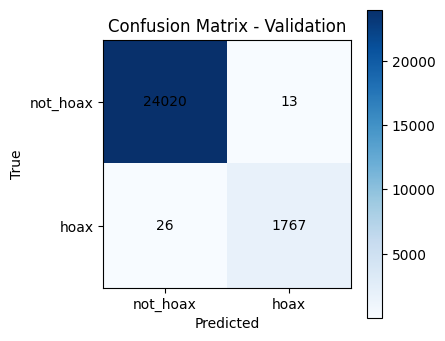


--- Test Classification Report ---
              precision    recall  f1-score   support

    not_hoax     0.9988    0.9999    0.9993     24034
        hoax     0.9983    0.9833    0.9907      1793

    accuracy                         0.9987     25827
   macro avg     0.9985    0.9916    0.9950     25827
weighted avg     0.9987    0.9987    0.9987     25827


--- Test Confusion Matrix ---
[[24031     3]
 [   30  1763]]


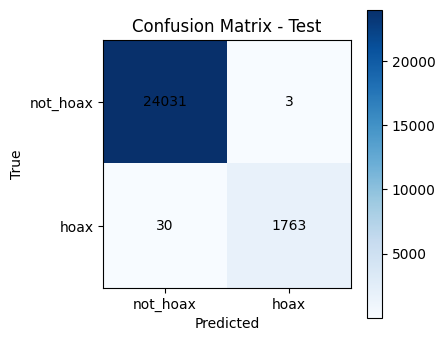

In [13]:
# 8. Laporan detail
def detailed_report(trainer: Trainer, dataset: Dataset, split_name: str):
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=-1)

    target_names = ["not_hoax", "hoax"]
    print(f"\n--- {split_name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n--- {split_name} Confusion Matrix ---")
    print(cm)

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    plt.title(f"Confusion Matrix - {split_name}")
    plt.colorbar(im, ax=ax)
    plt.show()


detailed_report(trainer, val_ds, "Validation")
detailed_report(trainer, test_ds, "Test")

In [14]:
# 9. Simpan model dan tokenizer
os.makedirs(cfg.output_dir, exist_ok=True)
trainer.model.save_pretrained(cfg.output_dir)
tokenizer.save_pretrained(cfg.output_dir)
print(f"\nModel & tokenizer disimpan ke: {cfg.output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model & tokenizer disimpan ke: indobert_hoax_model_v3


In [18]:
# 10. Download model
import shutil
from google.colab import files

output_filename = f"{cfg.output_dir}.zip"

print(f"Membuat zip: {cfg.output_dir}...")
shutil.make_archive(cfg.output_dir, 'zip', cfg.output_dir)

print(f"Mengunduh file: {output_filename}...")
files.download(output_filename)
print("Akhirnya siap!")

Membuat zip: indobert_hoax_model_v3...
Mengunduh file: indobert_hoax_model_v3.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Akhirnya siap!


## 11. Inferensi Multi-Paragraf (Sentence-Level + Topic)

Bagian ini **tidak mengubah training classifier IndoBERT**. Semua proses di bawah adalah post-processing saat inferensi untuk:
- split paragraf dan kalimat,
- klasifikasi per kalimat dengan model doc-level yang sama,
- agregasi label paragraf dan ringkasan dokumen,
- ekstraksi topik ringan per paragraf berbasis TF-IDF keyword.


In [15]:
# 11. Utilities inferensi multi-paragraf (post-processing)
import re
from collections import defaultdict
from typing import Any
from sklearn.feature_extraction.text import TfidfVectorizer

PARAGRAPH_SPLIT_RE = re.compile(r"(?:\r?\n){2,}")
SENTENCE_SPLIT_RE = re.compile(r'[^.!?]+(?:[.!?]+(?:["\)\]]+)?)|[^.!?]+$')
WS_RE = re.compile(r"\s+")
TOKEN_RE = re.compile(r"[a-zA-Z]{3,}")

ID_STOPWORDS = {
    "yang", "dan", "atau", "di", "ke", "dari", "untuk", "dengan", "pada",
    "adalah", "itu", "ini", "dalam", "sebagai", "karena", "juga", "agar",
    "oleh", "saat", "akan", "telah", "sudah", "tidak", "iya", "ya", "kita",
    "mereka", "kami", "anda", "hingga", "lebih", "masih", "dapat", "bisa",
    "dalam", "setelah", "sebelum", "tersebut", "terhadap", "disebut", "menurut",
}

def normalize_unit_text(text: str) -> str:
    return WS_RE.sub(" ", str(text)).strip()

def split_paragraphs(text: str):
    raw = str(text).strip()
    if not raw:
        return []
    paragraphs = [p.strip() for p in PARAGRAPH_SPLIT_RE.split(raw) if p.strip()]
    return paragraphs if paragraphs else [raw]

def split_sentences(paragraph: str):
    normalized = normalize_unit_text(paragraph)
    if not normalized:
        return []
    sentences = [m.group(0).strip() for m in SENTENCE_SPLIT_RE.finditer(normalized)]
    return [s for s in sentences if s] or [normalized]

def predict_texts_batched(texts, batch_size=64):
    if not texts:
        return []

    probs_all = []
    model.eval()
    for i in range(0, len(texts), batch_size):
        chunk = [normalize_unit_text(t) if normalize_unit_text(t) else "[EMPTY]" for t in texts[i:i+batch_size]]
        enc = tokenizer(
            chunk,
            truncation=True,
            max_length=cfg.max_length,
            padding=True,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        probs_all.extend(probs)

    results = []
    for row in probs_all:
        p_not_hoax = float(row[0])
        p_hoax = float(row[1])
        label = "hoax" if p_hoax >= 0.5 else "not_hoax"
        confidence = max(p_hoax, p_not_hoax)
        color = "red" if label == "hoax" else ("amber" if confidence < 0.70 else "green")
        results.append({
            "label": label,
            "probabilities": {"not_hoax": round(p_not_hoax, 6), "hoax": round(p_hoax, 6)},
            "hoax_probability": round(p_hoax, 6),
            "confidence": round(confidence, 6),
            "color": color,
        })
    return results

def extract_topics_tfidf(paragraph_texts, top_k=3, max_features=1500):
    if not paragraph_texts:
        return []

    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=max_features,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
        stop_words=list(ID_STOPWORDS),
    )

    topics = []
    try:
        matrix = vectorizer.fit_transform(paragraph_texts)
        features = vectorizer.get_feature_names_out()

        for i in range(matrix.shape[0]):
            row = matrix.getrow(i)
            if row.nnz == 0:
                tokens = [t for t in TOKEN_RE.findall(paragraph_texts[i].lower()) if t not in ID_STOPWORDS]
                uniq = []
                for t in tokens:
                    if t not in uniq:
                        uniq.append(t)
                keywords = uniq[:top_k] if uniq else ["topik_umum"]
                score = 0.0
            else:
                pairs = sorted(
                    zip(row.indices, row.data),
                    key=lambda x: (-x[1], features[x[0]])
                )[:top_k]
                keywords = [features[idx] for idx, _ in pairs]
                score = float(np.mean([v for _, v in pairs])) if pairs else 0.0

            topic_label = " / ".join(keywords[:2]) if keywords else "topik_umum"
            topics.append({
                "label": topic_label,
                "score": round(score, 6),
                "keywords": keywords[:top_k],
            })
    except Exception:
        for text in paragraph_texts:
            tokens = [t for t in TOKEN_RE.findall(text.lower()) if t not in ID_STOPWORDS]
            uniq = []
            for t in tokens:
                if t not in uniq:
                    uniq.append(t)
            keywords = uniq[:top_k] if uniq else ["topik_umum"]
            topics.append({
                "label": " / ".join(keywords[:2]) if keywords else "topik_umum",
                "score": 0.0,
                "keywords": keywords[:top_k],
            })

    return topics

def analyze_multi_paragraph(text: str, sentence_batch_size: int = 64) -> Dict[str, Any]:
    raw_text = str(text).strip()
    if not raw_text:
        return {
            "document": {
                "label": "not_hoax",
                "hoax_probability": 0.0,
                "confidence": 0.0,
                "risk_level": "low",
                "sentence_aggregate_label": "not_hoax",
                "summary": {
                    "paragraph_count": 0,
                    "sentence_count": 0,
                    "hoax_sentence_count": 0,
                    "not_hoax_sentence_count": 0,
                },
            },
            "paragraphs": [],
            "shared_topics": [],
        }

    # Doc-level utama (baseline classifier, no-regression path)
    doc_pred = predict_texts_batched([raw_text], batch_size=1)[0]

    paragraphs = split_paragraphs(raw_text)
    sentence_texts = []
    sentence_map = []

    for p_idx, paragraph in enumerate(paragraphs):
        sents = split_sentences(paragraph)
        for s_idx, sent in enumerate(sents):
            sentence_texts.append(sent)
            sentence_map.append((p_idx, s_idx))

    sentence_preds = predict_texts_batched(sentence_texts, batch_size=sentence_batch_size)

    paragraph_objs = [
        {
            "paragraph_index": i,
            "text": p,
            "sentences": [],
        }
        for i, p in enumerate(paragraphs)
    ]

    for (p_idx, s_idx), sent_text, pred in zip(sentence_map, sentence_texts, sentence_preds):
        paragraph_objs[p_idx]["sentences"].append({
            "sentence_index": s_idx,
            "text": sent_text,
            **pred,
        })

    topics = extract_topics_tfidf([p["text"] for p in paragraph_objs])

    hoax_sentence_count = 0
    non_hoax_sentence_count = 0

    for i, paragraph_obj in enumerate(paragraph_objs):
        sentences = paragraph_obj["sentences"]
        if not sentences:
            paragraph_obj["label"] = "not_hoax"
            paragraph_obj["hoax_probability"] = 0.0
            paragraph_obj["confidence"] = 0.0
        else:
            hoax_flags = [s["label"] == "hoax" for s in sentences]
            paragraph_obj["label"] = "hoax" if any(hoax_flags) else "not_hoax"
            paragraph_obj["hoax_probability"] = round(max(s["hoax_probability"] for s in sentences), 6)
            paragraph_obj["confidence"] = round(max(s["confidence"] for s in sentences), 6)

            hoax_sentence_count += sum(1 for s in sentences if s["label"] == "hoax")
            non_hoax_sentence_count += sum(1 for s in sentences if s["label"] == "not_hoax")

        paragraph_obj["topic"] = topics[i]

    sentence_aggregate_label = "hoax" if hoax_sentence_count > 0 else "not_hoax"

    topic_to_paragraphs = defaultdict(list)
    for p in paragraph_objs:
        topic_to_paragraphs[p["topic"]["label"]].append(p["paragraph_index"])

    shared_topics = [
        {"label": label, "paragraph_indices": idxs}
        for label, idxs in topic_to_paragraphs.items()
        if len(idxs) > 1
    ]

    shared_topics = sorted(shared_topics, key=lambda x: (x["paragraph_indices"][0], x["label"]))

    return {
        "document": {
            "label": doc_pred["label"],
            "hoax_probability": doc_pred["hoax_probability"],
            "confidence": doc_pred["confidence"],
            "risk_level": "high" if doc_pred["hoax_probability"] > 0.98 else ("medium" if doc_pred["hoax_probability"] > 0.60 else "low"),
            "sentence_aggregate_label": sentence_aggregate_label,
            "summary": {
                "paragraph_count": len(paragraph_objs),
                "sentence_count": len(sentence_preds),
                "hoax_sentence_count": hoax_sentence_count,
                "not_hoax_sentence_count": non_hoax_sentence_count,
            },
        },
        "paragraphs": paragraph_objs,
        "shared_topics": shared_topics,
    }

print("Utilities inferensi V1 siap.")


Utilities inferensi V1 siap.


## 12. Demo Inferensi V1

Contoh berikut menunjukkan deteksi multi-paragraf, highlight kalimat hoaks/fakta, dan topik per paragraf.


In [16]:
contoh_teks_multi_paragraf = """
Beredar unggahan media sosial yang menyebut pemerintah membagikan bantuan tunai langsung tanpa syarat lewat tautan tertentu. Banyak akun meminta warga mengisi data pribadi dan OTP agar dana cair hari itu juga.

Kementerian terkait kemudian merilis klarifikasi bahwa informasi tersebut tidak benar dan meminta masyarakat tidak membagikan tautan yang tidak berasal dari kanal resmi. Warga diminta cek pengumuman hanya lewat situs resmi pemerintah.

Sejumlah komentar pengguna juga menuliskan pengalaman bahwa tautan serupa berujung pada permintaan data rekening. Pakar keamanan digital menyarankan verifikasi sumber sebelum menyebarkan pesan berantai.
"""

hasil_v1 = analyze_multi_paragraph(contoh_teks_multi_paragraf, sentence_batch_size=64)
print("Document:", hasil_v1["document"])
print("")
for p in hasil_v1["paragraphs"]:
    print(f"[Paragraf {p['paragraph_index']}] label={p['label']} topic={p['topic']['label']} score={p['topic']['score']}")
    for s in p["sentences"]:
        print(
            f"  - ({s['sentence_index']}) {s['label']} | p_hoax={s['hoax_probability']:.4f} | conf={s['confidence']:.4f} | color={s['color']}"
        )
    print("")

print("Shared topics:", hasil_v1["shared_topics"])


Document: {'label': 'not_hoax', 'hoax_probability': 0.021657, 'confidence': 0.978343, 'risk_level': 'low', 'sentence_aggregate_label': 'hoax', 'summary': {'paragraph_count': 3, 'sentence_count': 6, 'hoax_sentence_count': 5, 'not_hoax_sentence_count': 1}}

[Paragraf 0] label=hoax topic=akun / akun meminta score=0.14461
  - (0) hoax | p_hoax=0.9999 | conf=0.9999 | color=red
  - (1) hoax | p_hoax=0.9999 | conf=0.9999 | color=red

[Paragraf 1] label=hoax topic=resmi / bahwa informasi score=0.196977
  - (0) hoax | p_hoax=0.9994 | conf=0.9994 | color=red
  - (1) hoax | p_hoax=0.9998 | conf=0.9998 | color=red

[Paragraf 2] label=hoax topic=bahwa tautan / berantai score=0.1591
  - (0) hoax | p_hoax=0.8404 | conf=0.8404 | color=red
  - (1) not_hoax | p_hoax=0.0499 | conf=0.9501 | color=green

Shared topics: []


## No-Regression Guarantee

1. **Training core baseline tidak diubah secara semantik**: IndoBERT doc-level tetap dilatih dengan alur yang sama seperti notebook baseline (`split 70/15/15`, balancing hanya di train, dan classifier biner).
2. **Sentence-level dan topic adalah post-processing inferensi**: tidak ada fine-tuning sentence-level tambahan, sehingga tidak menambah beban training classifier.
3. **Verifikasi no-regression dilakukan di Colab (GPU T4)**, bukan lokal:
   - Jalankan cell training baseline di notebook V1.
   - Bandingkan metrik validasi/test (accuracy dan F1 hoax) dengan baseline sebelumnya.
   - Pastikan penambahan fitur inferensi (sentence-level + topic) tidak mengubah metrik training doc-level.


In [17]:
# 13. Push model hasil training ke Hugging Face (TA-FINAL)
!pip install -q huggingface_hub

from huggingface_hub import login, HfApi
from google.colab import userdata

try:
    token_kredensial = userdata.get('HF_TOKEN')
    login(token=token_kredensial)
except Exception:
    print("Token HF_TOKEN tidak ditemukan pada Colab Secrets.")

api_huggingface = HfApi()
id_repositori_target = "fjrmhri/TA-FINAL"
direktori_sumber_artefak = f"/content/{cfg.output_dir}"

api_huggingface.create_repo(repo_id=id_repositori_target, private=False, exist_ok=True)

print(f"Memulai unggahan dari {direktori_sumber_artefak} menuju {id_repositori_target}...")
api_huggingface.upload_folder(
    folder_path=direktori_sumber_artefak,
    repo_id=id_repositori_target,
    repo_type="model",
    commit_message="Pembaruan model IndoBERT deteksi hoaks (V1)"
)
print(f"Transmisi selesai. URL Repositori: https://huggingface.co/{id_repositori_target}")


Token HF_TOKEN tidak ditemukan pada Colab Secrets.
Memulai unggahan dari /content/indobert_hoax_model_v3 menuju fjrmhri/TA-FINAL...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckpoint-3500/optimizer.pt:   0%|          | 3.59MB /  885MB            

  ...ckpoint-3507/optimizer.pt:   0%|          | 3.59MB /  885MB            

...

  ...nt-3507/model.safetensors:   1%|          | 3.92MB /  442MB            

  ...checkpoint-3500/scaler.pt:   9%|9         |   127B / 1.38kB            

  ...ckpoint-3500/scheduler.pt:   9%|9         |   134B / 1.47kB            

  ...nt-3500/training_args.bin:   9%|9         |   473B / 5.14kB            

Transmisi selesai. URL Repositori: https://huggingface.co/fjrmhri/TA-FINAL


## BERTopic Topic Modeling (Post-Training)

Bagian ini berjalan setelah training classifier IndoBERT selesai. BERTopic hanya dipakai untuk topic modeling pada korpus teks dan tidak masuk ke loop training classifier.


In [ ]:
# 14. Import BERTopic stack
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import re


In [ ]:
# 15. Fit BERTopic pada korpus training (post-training)
if not ENABLE_BERTOPIC:
    topic_model = None
    bertopic_docs = []
    bertopic_topics = []
    bertopic_probs = None
    print("ENABLE_BERTOPIC=False, proses BERTopic dilewati.")
else:
    bertopic_docs = train_df["text"].astype(str).tolist()

    if BERTOPIC_MAX_DOCS is not None and BERTOPIC_MAX_DOCS > 0 and len(bertopic_docs) > BERTOPIC_MAX_DOCS:
        rng = random.Random(BERTOPIC_RANDOM_SEED)
        bertopic_docs = rng.sample(bertopic_docs, BERTOPIC_MAX_DOCS)

    print(f"Total dokumen untuk BERTopic: {len(bertopic_docs)}")

    embed_device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device embedding BERTopic:", embed_device)

    sentence_embedder = SentenceTransformer(BERTOPIC_EMBEDDING_MODEL, device=embed_device)

    embeddings = sentence_embedder.encode(
        bertopic_docs,
        batch_size=BERTOPIC_EMBED_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    print("Shape embeddings:", embeddings.shape)

    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=BERTOPIC_RANDOM_SEED,
        low_memory=True,
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=15,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    vectorizer_model = CountVectorizer(ngram_range=(1, 2), min_df=5)

    topic_model = BERTopic(
        language="multilingual",
        calculate_probabilities=True,
        verbose=True,
        embedding_model=None,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
    )

    bertopic_topics, bertopic_probs = topic_model.fit_transform(bertopic_docs, embeddings)

    topic_info = topic_model.get_topic_info()
    print("
Ringkasan topik BERTopic:")
    print(topic_info.head(10))


In [ ]:
# 16. Simpan artefak BERTopic ke /content dan zip
if ENABLE_BERTOPIC and topic_model is not None:
    os.makedirs(BERTOPIC_OUTPUT_DIR, exist_ok=True)

    try:
        topic_model.save(BERTOPIC_OUTPUT_DIR, serialization="safetensors")
        print(f"Model BERTopic disimpan (safetensors) ke: {BERTOPIC_OUTPUT_DIR}")
    except TypeError:
        topic_model.save(BERTOPIC_OUTPUT_DIR)
        print(f"Model BERTopic disimpan (default) ke: {BERTOPIC_OUTPUT_DIR}")

    bertopic_zip_path = shutil.make_archive(BERTOPIC_OUTPUT_DIR, "zip", BERTOPIC_OUTPUT_DIR)
    print(f"Artefak BERTopic di-zip ke: {bertopic_zip_path}")
else:
    print("Model BERTopic belum tersedia; proses simpan dilewati.")


In [ ]:
# 17. Demo inferensi topik per paragraf
PARAGRAPH_SPLIT_RE_BERTOPIC = re.compile(r"(?:\r?\n){2,}")


def split_paragraphs_for_topic(text: str):
    # Pakai util yang sudah ada bila tersedia, fallback ke regex lokal.
    if "split_paragraphs" in globals() and callable(split_paragraphs):
        return split_paragraphs(text)
    raw = str(text).strip()
    if not raw:
        return []
    parts = [p.strip() for p in PARAGRAPH_SPLIT_RE_BERTOPIC.split(raw) if p.strip()]
    return parts if parts else [raw]


def get_topic_label(topic_model_obj, topic_id: int) -> str:
    info = topic_model_obj.get_topic_info()
    row = info[info["Topic"] == topic_id]
    if len(row) > 0 and "Name" in row.columns:
        return str(row.iloc[0]["Name"])

    words = topic_model_obj.get_topic(topic_id)
    if words:
        return " / ".join([w for w, _ in words[:3]])
    return "topik_tidak_dikenal"


def assigned_topic_score(prob_row, topic_id):
    if prob_row is None:
        return None
    if isinstance(prob_row, np.ndarray):
        if prob_row.ndim == 0:
            return float(prob_row)
        if topic_id >= 0 and topic_id < len(prob_row):
            return float(prob_row[topic_id])
        return float(np.max(prob_row)) if prob_row.size > 0 else None
    return None


contoh_teks_topik = """
Beredar tautan bantuan tunai yang meminta OTP pengguna.

Kementerian mengklarifikasi bahwa tautan tersebut palsu dan meminta warga cek kanal resmi.

Pengguna lain melaporkan modus serupa berujung pada pencurian akun.
"""

if ENABLE_BERTOPIC and topic_model is not None:
    paragraf = split_paragraphs_for_topic(contoh_teks_topik)
    print("Jumlah paragraf:", len(paragraf))

    if paragraf:
        para_embeddings = sentence_embedder.encode(
            paragraf,
            batch_size=BERTOPIC_EMBED_BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )

        para_topics, para_probs = topic_model.transform(paragraf, embeddings=para_embeddings)

        print("\nHasil topik per paragraf:")
        for idx, (text_p, t_id) in enumerate(zip(paragraf, para_topics)):
            p_row = para_probs[idx] if para_probs is not None else None
            t_score = assigned_topic_score(p_row, t_id)
            t_label = get_topic_label(topic_model, t_id)
            score_text = f"{t_score:.4f}" if t_score is not None else "N/A"
            print(f"- Paragraf {idx}: Topik {t_id} | {t_label} | score={score_text}")
            print(f"  Teks: {text_p}\n")
else:
    print("Demo BERTopic dilewati karena model belum di-fit.")


In [ ]:
# 18. (Opsional) Upload artefak BERTopic ke Hugging Face repo terpisah (OFF by default)
if not ENABLE_BERTOPIC_UPLOAD:
    print("ENABLE_BERTOPIC_UPLOAD=False. Upload BERTopic dilewati.")
elif not ENABLE_BERTOPIC or topic_model is None:
    print("Model BERTopic belum tersedia. Jalankan proses fit terlebih dahulu.")
else:
    from huggingface_hub import login, HfApi
    from google.colab import userdata

    try:
        token_kredensial = userdata.get("HF_TOKEN")
        login(token=token_kredensial)
    except Exception:
        print("Token HF_TOKEN tidak ditemukan pada Colab Secrets.")

    api_huggingface = HfApi()
    repo_id_topic = BERTOPIC_TOPIC_REPO_ID
    direktori_sumber_topik = BERTOPIC_OUTPUT_DIR

    api_huggingface.create_repo(repo_id=repo_id_topic, private=False, exist_ok=True)

    print(f"Memulai unggahan BERTopic dari {direktori_sumber_topik} ke {repo_id_topic}...")
    api_huggingface.upload_folder(
        folder_path=direktori_sumber_topik,
        repo_id=repo_id_topic,
        repo_type="model",
        commit_message="Upload BERTopic artifacts (V1 post-training)",
    )
    print(f"Upload BERTopic selesai: https://huggingface.co/{repo_id_topic}")
